In [1]:
%cd ..

/home/blanka/Multi-Domain-Pruning


In [2]:
import torch
import matplotlib.pyplot as plt
from utils.config_parser import ConfigParser
from state_predictor.dataloader import create_pruning_dataloader

def plot_label_histogram(dataloader, value_index, value_name, max_batches=100, bins=50):

    all_values = []

    for batch_i, (data_gt, label_gt, state_df, label_df) in enumerate(dataloader):
        if batch_i >= max_batches:
            break

        # label_gt assumed to be shape (batch_size, 2) or similar
        values = label_gt[:, value_index].cpu().numpy()
        all_values.extend(values)

    if not all_values:
        print("No values found to plot.")
        return

    plt.figure(figsize=(8, 5))
    plt.hist(all_values, bins=bins, edgecolor='black')
    plt.title(f"Histogram of {value_name}")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


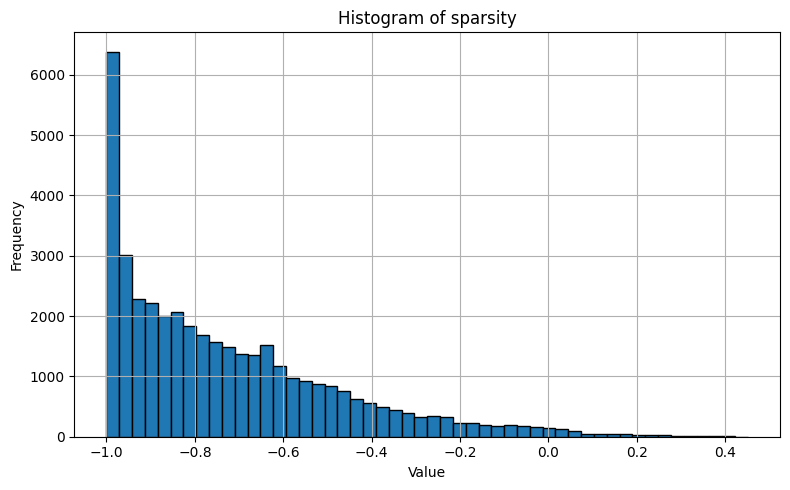

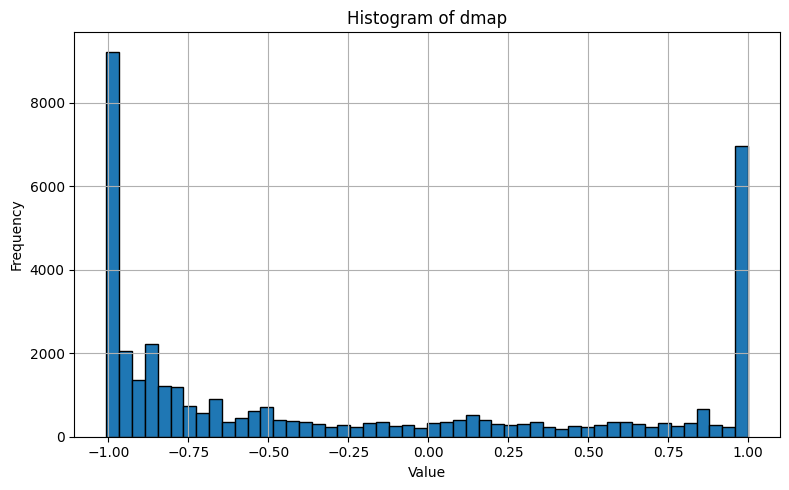

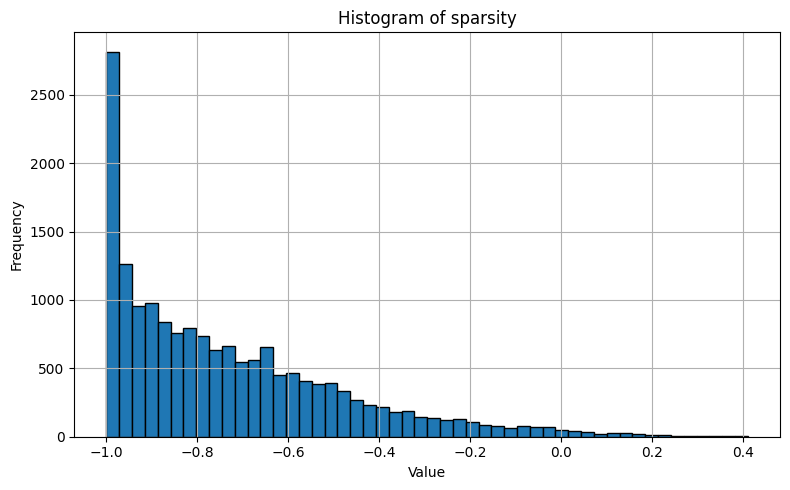

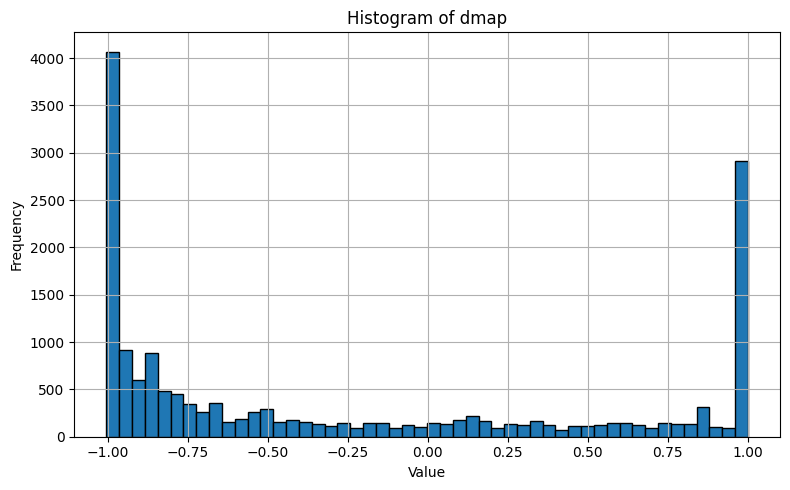

In [3]:

conf = ConfigParser.read("config/spn.ini")
train_dataloader = create_pruning_dataloader(conf, split_type="training")

plot_label_histogram(train_dataloader, value_index=0, value_name="sparsity", max_batches=500000)
plot_label_histogram(train_dataloader, value_index=1, value_name="dmap", max_batches=500000)

val_dataloader = create_pruning_dataloader(conf, split_type="validation")

plot_label_histogram(val_dataloader, value_index=0, value_name="sparsity", max_batches=500000)
plot_label_histogram(val_dataloader, value_index=1, value_name="dmap", max_batches=500000)